In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\regression\bigmartsales.csv")


In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
df['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [5]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [8]:
mean = df['Item_Weight'].mean()
df['Item_Weight'].fillna(mean,inplace = True)


mode = df['Outlet_Size'].mode()
df['Outlet_Size'].fillna(mode[0],inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_19824\1617551846.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean,inplace = True)


In [10]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [11]:
df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1, inplace=True)
df.head()

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,Low Fat,0.016047,Dairy,249.8092,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,5.92,Regular,0.019278,Soft Drinks,48.2692,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,17.50,Low Fat,0.016760,Meat,141.6180,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,1998,Medium,Tier 3,Grocery Store,732.3800
4,8.93,Low Fat,0.000000,Household,53.8614,1987,High,Tier 3,Supermarket Type1,994.7052


In [12]:
df = pd.get_dummies(df)

In [13]:
from sklearn.model_selection import train_test_split
train,test = train_test_split(df,test_size = 0.3,random_state=42)

x_train = train.drop('Item_Outlet_Sales',axis = 1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales',axis = 1)
y_test = test['Item_Outlet_Sales']

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

x_trained_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_trained_scaled)

x_test_scaled = scaler.fit_transform(x_test)
x_test = pd.DataFrame(x_test_scaled)

In [15]:
x_test

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
0,0.579356,0.084541,0.201879,0.083333,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.199284,0.228666,0.045282,0.500000,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.591289,0.132801,0.042454,0.583333,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.493296,0.143904,0.603908,0.000000,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.334427,0.040039,0.705425,0.791667,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,0.463007,0.527811,0.377070,0.583333,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2553,0.051909,0.103415,0.651322,0.791667,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2554,0.821002,0.478763,0.681712,0.541667,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2555,0.322792,0.122080,0.411983,0.916667,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [16]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error


In [17]:
model = neighbors.KNeighborsRegressor(n_neighbors=9)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [19]:
RMSE_val = []

for K in range(20):
  K = K + 1
  model = neighbors.KNeighborsRegressor(n_neighbors=K)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)

  error = np.sqrt(mean_squared_error(y_test,y_pred))
  RMSE_val.append(error)
  print("rmse value of K=",K,"is:",error)

rmse value of K= 1 is: 1547.777838766353
rmse value of K= 2 is: 1334.4451325280584
rmse value of K= 3 is: 1276.270772538593
rmse value of K= 4 is: 1249.2192037376255
rmse value of K= 5 is: 1225.9648795409605
rmse value of K= 6 is: 1203.2035346499208
rmse value of K= 7 is: 1205.3051701035872
rmse value of K= 8 is: 1207.8791408411082
rmse value of K= 9 is: 1206.7500205514377
rmse value of K= 10 is: 1206.5700927558685
rmse value of K= 11 is: 1212.0521949031797
rmse value of K= 12 is: 1216.9933077826204
rmse value of K= 13 is: 1217.9354029440497
rmse value of K= 14 is: 1222.9139555348086
rmse value of K= 15 is: 1225.366855635553
rmse value of K= 16 is: 1228.6855178916094
rmse value of K= 17 is: 1233.058219803193
rmse value of K= 18 is: 1234.5653266882503
rmse value of K= 19 is: 1240.6318969344525
rmse value of K= 20 is: 1245.793397865301


<Axes: >

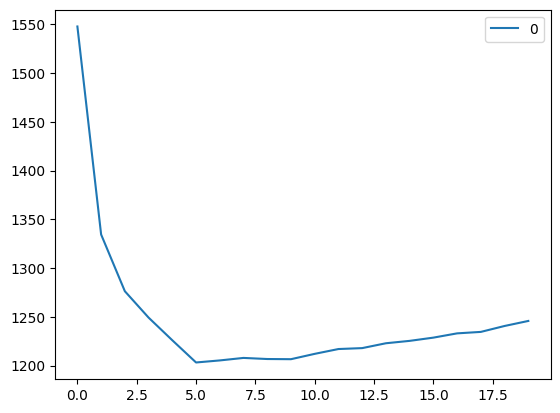

In [21]:
curve = pd.DataFrame(RMSE_val)
curve.plot()

In [22]:
test = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\ml\regression\bigmartsales_Test.csv")
submission = pd.DataFrame()
submission['Item_Identifier'] = test['Item_Identifier']
submission['Outlet_Identifier'] = test['Outlet_Identifier']

test.drop(['Item_Identifier','Outlet_Identifier'],axis = 1,inplace = True)
test['Item_Weight'].fillna(mean,inplace = True)



C:\Users\DELL\AppData\Local\Temp\ipykernel_19824\3520939147.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Item_Weight'].fillna(mean,inplace = True)


In [23]:
test = pd.get_dummies(test)
test_scaled = scaler.fit_transform(test)
test = pd.DataFrame(test_scaled)

In [24]:
pred = model.predict(test)
submission['Item_Outlet_Sales'] = pred
submission.to_csv('submit_file_for_kaggle.csv',index = False)

In [26]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors':[2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]}

knn = neighbors.KNeighborsRegressor()

model = GridSearchCV(knn,params,cv = 3)
model.fit(x_train,y_train)
model.best_params_

{'n_neighbors': 8}